<a href="https://colab.research.google.com/github/saramendesoliveiralima/cursodeautomacaodetestesweb/blob/master/SARA_LIMA_Atividade_Perceptron_e_MLP_com_scripts_programados_com_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade - Perceptron e MLP com scripts programados com PyTorch**

**Observação:** Os trabalhos serão avaliados apenas se implementados por PyTorch.

*   **Nome**: Sara Mendes Oliveira Lima
*   **Matrícula**: 261112448

---

# **Diagnóstico de Diabetes com Redes Neurais**

Nesta atividade, vamos trabalhar com um problema aplicado de **classificação binária**: prever se uma pessoa possui ou não diabetes com base em um conjunto de variáveis clínicas.

[Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

---

## **Contexto**

- O dataset utilizado é o **Pima Indians Diabetes Dataset**, coletado originalmente pelo Instituto Nacional de Diabetes e Doenças Digestivas e Renais dos Estados Unidos.
- Ele contém registros de mulheres com pelo menos 21 anos de idade da população Pima, um grupo étnico nativo norte-americano com alta incidência de diabetes tipo 2.

## **Objetivo**

O objetivo é treinar uma MLP para prever a presença de diabetes a partir de atributos fisiológicos e laboratoriais.

## **Variáveis de entrada**

Cada observação contém os seguintes atributos:

1. **Pregnancies**, number of times pregnant: Variável discreta.
2. **Glucose**, plasma glucose concentration after 2 hours in an oral glucose tolerance test: Variável contínua.
3. **BloodPressure**, diastolic blood pressure, in mm Hg: Variável contínua.
4. **SkinThickness**, triceps skin fold thickness, in mm: Variável contínua.
5. **Insulin**, 2-hour serum insulin, in μU/mL: Variável contínua.
6. **BMI**, body mass index, weight in kg/(height in m)²: Variável contínua.
7. **DiabetesPedigreeFunction**, family history function: Variável contínua.
8. **Age**, in years: : Variável discreta.

## **Variáveis de saída (Target)**

- **Outcome = 1**: Diabetic
- **Outcome = 0**: Non-diabetic


# **Exercício 1 - Preparação dos dados**

1. Apresente um resumo estatístico básico e visualizações simples, como correlação entre variáveis e histogramas procurando inconsistências que podem afetar a construção do modelo.
2. Faça a divisão dos dados:
  - 70% para treino
  - 15% para validação
  - 15% para teste

Use como exemplo a aula colab do dia 21/05/2025.
```python
import pandas as pd

# URL do dataset
url = "https://raw.githubusercontent.com/pcbrom/perceptron-mlp-cnn/refs/heads/main/data/diabetes.csv"

# Carregar o dataset
df = pd.read_csv(url)
```



**Apresente um resumo estatístico básico e visualizações simples, como correlação entre variáveis e histogramas procurando inconsistências que podem afetar a construção do modelo.**

**Importando a biblioteca do Panda:**

In [2]:
import pandas as pd

**Carregando o DataSet:**

In [3]:
url = "https://raw.githubusercontent.com/pcbrom/perceptron-mlp-cnn/refs/heads/main/data/diabetes.csv"

In [4]:
df = pd.read_csv(url)

**Resumo estatístico básico das variáveis:**

In [5]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

**Verificando se existem valores ausentes:**

In [ ]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


**Verificando a distribuição das classes:**

In [ ]:
print(df['Pregnancies'].value_counts())

Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
17      1
15      1
Name: count, dtype: int64


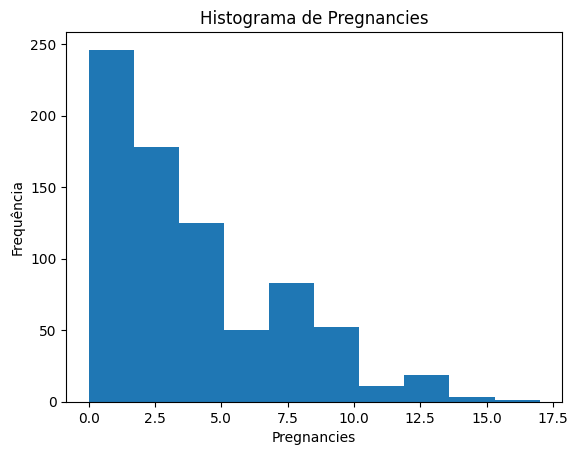

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['Pregnancies'], bins=10)

plt.title('Histograma de Pregnancies')
plt.xlabel('Pregnancies')
plt.ylabel('Frequência')

plt.show()

In [ ]:
print(df['Glucose'].value_counts())

Glucose
99     17
100    17
111    14
125    14
129    14
       ..
56      1
169     1
149     1
65      1
190     1
Name: count, Length: 136, dtype: int64


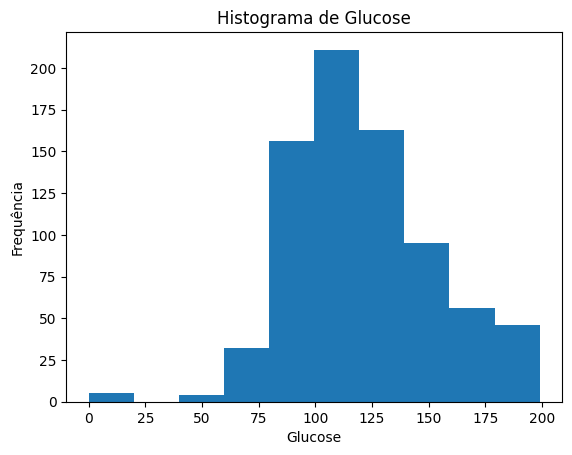

In [ ]:
import matplotlib.pyplot as plt


plt.hist(df['Glucose'], bins=10)

plt.title('Histograma de Glucose')
plt.xlabel('Glucose')
plt.ylabel('Frequência')

plt.show()

In [ ]:
print(df['BloodPressure'].value_counts())

BloodPressure
70     57
74     52
78     45
68     45
72     44
64     43
80     40
76     39
60     37
0      35
62     34
66     30
82     30
88     25
84     23
90     22
86     21
58     21
50     13
56     12
54     11
52     11
92      8
75      8
65      7
85      6
94      6
48      5
44      4
96      4
110     3
106     3
100     3
98      3
30      2
46      2
55      2
104     2
108     2
40      1
122     1
95      1
102     1
61      1
24      1
38      1
114     1
Name: count, dtype: int64


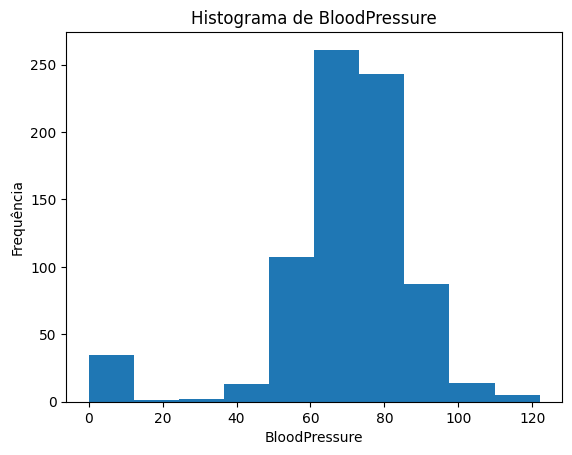

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['BloodPressure'], bins=10)

plt.title('Histograma de BloodPressure')
plt.xlabel('BloodPressure')
plt.ylabel('Frequência')

plt.show()

In [ ]:
print(df['SkinThickness'].value_counts())

SkinThickness
0     227
32     31
30     27
27     23
23     22
18     20
33     20
28     20
31     19
39     18
19     18
29     17
25     16
40     16
22     16
37     16
26     16
41     15
35     15
36     14
15     14
17     14
20     13
24     12
42     11
13     11
21     10
46      8
34      8
12      7
38      7
16      6
11      6
45      6
14      6
43      6
44      5
10      5
47      4
48      4
49      3
50      3
54      2
8       2
52      2
7       2
60      1
51      1
56      1
63      1
99      1
Name: count, dtype: int64


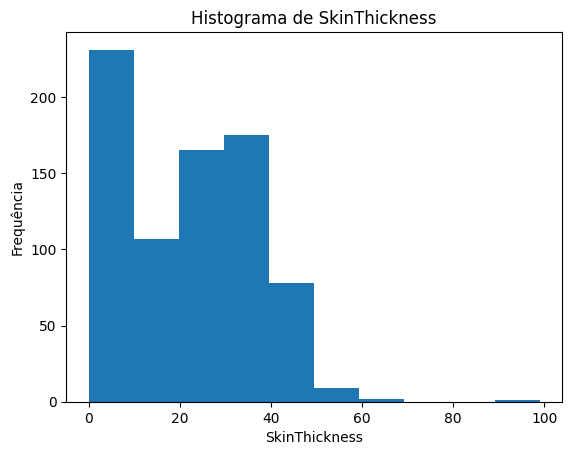

In [ ]:
plt.hist(df['SkinThickness'], bins=10)

plt.title('Histograma de SkinThickness')
plt.xlabel('SkinThickness')
plt.ylabel('Frequência')

plt.show()

In [ ]:
print(df['Insulin'].value_counts())

Insulin
0      374
105     11
130      9
140      9
120      8
      ... 
178      1
127      1
510      1
16       1
112      1
Name: count, Length: 186, dtype: int64


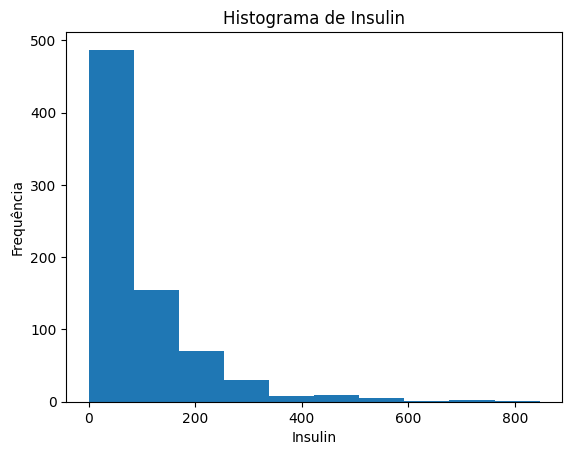

In [ ]:
plt.hist(df['Insulin'], bins=10)

plt.title('Histograma de Insulin')
plt.xlabel('Insulin')
plt.ylabel('Frequência')

plt.show()

In [ ]:
print(df['BMI'].value_counts())

BMI
32.0    13
31.6    12
31.2    12
0.0     11
32.4    10
        ..
49.6     1
24.1     1
41.2     1
49.3     1
46.3     1
Name: count, Length: 248, dtype: int64


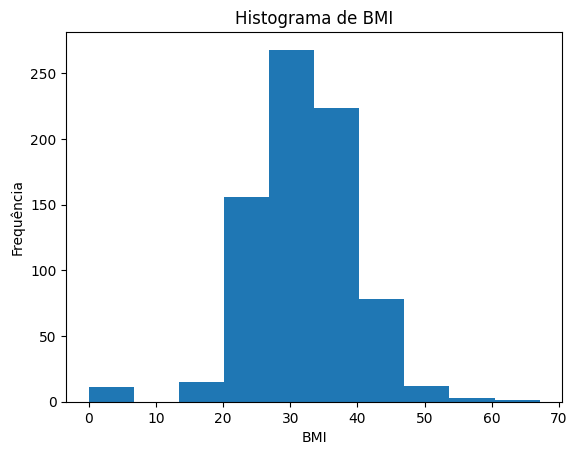

In [ ]:
plt.hist(df['BMI'], bins=10)

plt.title('Histograma de BMI')
plt.xlabel('BMI')
plt.ylabel('Frequência')

plt.show()

In [ ]:
print(df['DiabetesPedigreeFunction'].value_counts())

DiabetesPedigreeFunction
0.258    6
0.254    6
0.207    5
0.261    5
0.259    5
        ..
0.565    1
0.118    1
0.177    1
0.176    1
0.295    1
Name: count, Length: 517, dtype: int64


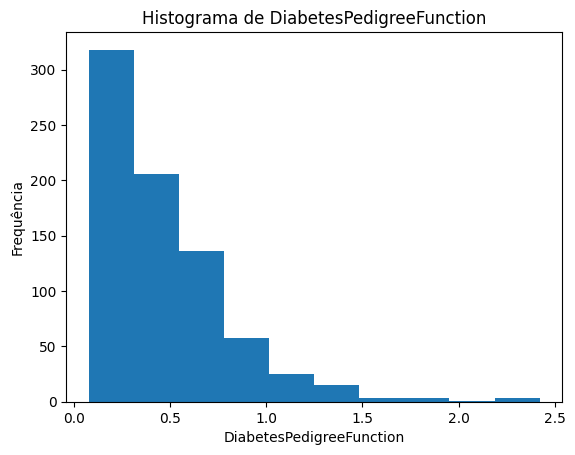

In [ ]:
plt.hist(df['DiabetesPedigreeFunction'], bins=10)

plt.title('Histograma de DiabetesPedigreeFunction')
plt.xlabel('DiabetesPedigreeFunction')
plt.ylabel('Frequência')

plt.show()

In [ ]:
print(df['Age'].value_counts())

Age
22    72
21    63
25    48
24    46
23    38
28    35
26    33
27    32
29    29
31    24
41    22
30    21
37    19
42    18
33    17
36    16
38    16
32    16
45    15
34    14
46    13
40    13
43    13
39    12
35    10
44     8
50     8
51     8
52     8
58     7
54     6
47     6
49     5
60     5
53     5
57     5
48     5
63     4
66     4
55     4
62     4
59     3
56     3
65     3
67     3
61     2
69     2
72     1
81     1
64     1
70     1
68     1
Name: count, dtype: int64


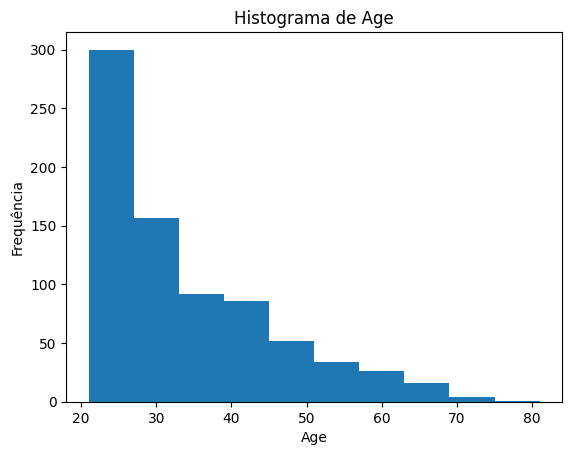

In [ ]:
plt.hist(df['Age'], bins=10)

plt.title('Histograma de Age')
plt.xlabel('Age')
plt.ylabel('Frequência')

plt.show()

In [ ]:
print(df['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


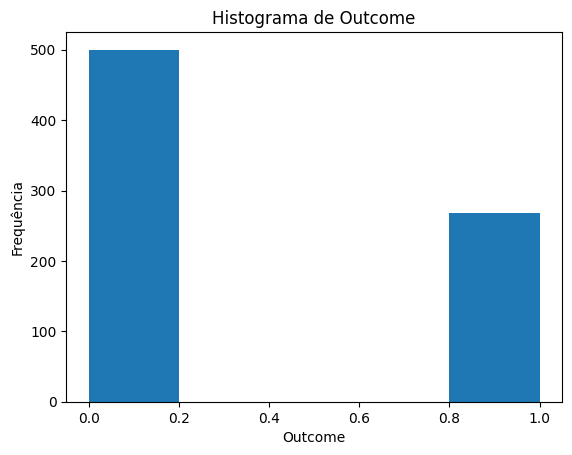

In [ ]:
plt.hist(df['Outcome'], bins=5)

plt.title('Histograma de Outcome')
plt.xlabel('Outcome')
plt.ylabel('Frequência')

plt.show()

**Correlação entre as variáveis:**

In [ ]:
corr = df.corr(numeric_only=True)

print(corr)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

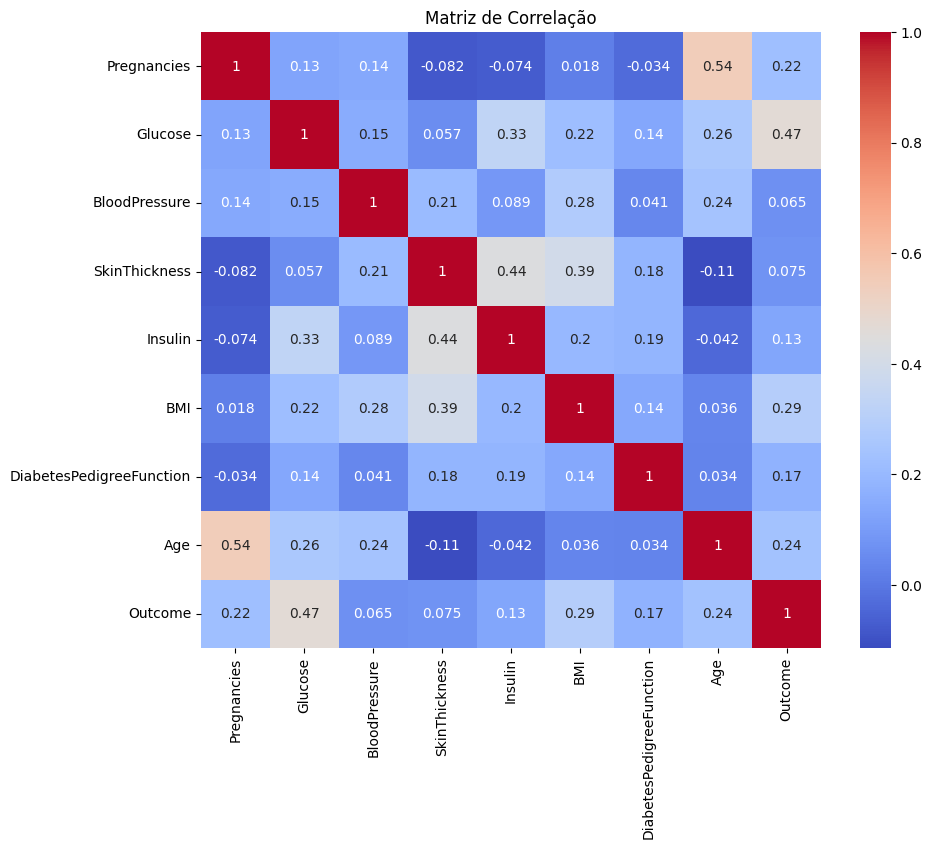

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de Correlação")
plt.show()

**Buscando inconsistências:**

**Pregnancies:**



In [ ]:
print(df[df['Pregnancies'] < 0])

Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


In [ ]:
print(df[df['Pregnancies'] > 20])

Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


**Glucose:**

In [ ]:
print(df[df['Glucose'] <= 0])

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
75             1        0             48             20        0  24.7   
182            1        0             74             20       23  27.7   
342            1        0             68             35        0  32.0   
349            5        0             80             32        0  41.0   
502            6        0             68             41        0  39.0   

     DiabetesPedigreeFunction  Age  Outcome  
75                      0.140   22        0  
182                     0.299   21        0  
342                     0.389   22        0  
349                     0.346   37        1  
502                     0.727   41        1  


**Blood Pressure:**

In [ ]:
print(df[df['BloodPressure'] == 0])

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
7             10      115              0              0        0  35.3   
15             7      100              0              0        0  30.0   
49             7      105              0              0        0   0.0   
60             2       84              0              0        0   0.0   
78             0      131              0              0        0  43.2   
81             2       74              0              0        0   0.0   
172            2       87              0             23        0  28.9   
193           11      135              0              0        0  52.3   
222            7      119              0              0        0  25.2   
261            3      141              0              0        0  30.0   
266            0      138              0              0        0  36.3   
269            2      146              0              0        0  27.5   
300            0      167             

In [ ]:
print(df[(df['BloodPressure'] > 0) & (df['BloodPressure'] <= 20)])

Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


In [ ]:
print(df[df['BloodPressure'] > 200])

Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


**Skin Thickness:**

In [ ]:
print(df[df['SkinThickness'] == 0])

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
2              8      183             64              0        0  23.3   
5              5      116             74              0        0  25.6   
7             10      115              0              0        0  35.3   
9              8      125             96              0        0   0.0   
10             4      110             92              0        0  37.6   
..           ...      ...            ...            ...      ...   ...   
757            0      123             72              0        0  36.3   
758            1      106             76              0        0  37.5   
759            6      190             92              0        0  35.5   
762            9       89             62              0        0  22.5   
766            1      126             60              0        0  30.1   

     DiabetesPedigreeFunction  Age  Outcome  
2                       0.672   32        1  
5                  

In [ ]:
print(df[df['SkinThickness'] > 80])

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
579            2      197             70             99        0  34.7   

     DiabetesPedigreeFunction  Age  Outcome  
579                     0.575   62        1  


**Insulin:**

In [ ]:
print(df[df['Insulin'] == 0])

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
5              5      116             74              0        0  25.6   
7             10      115              0              0        0  35.3   
..           ...      ...            ...            ...      ...   ...   
761            9      170             74             31        0  44.0   
762            9       89             62              0        0  22.5   
764            2      122             70             27        0  36.8   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [ ]:
print(df[df['Insulin'] > 1000])

Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


**BMI:**

In [ ]:
print(df[df['BMI'] == 0])

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI  \
9              8      125             96              0        0  0.0   
49             7      105              0              0        0  0.0   
60             2       84              0              0        0  0.0   
81             2       74              0              0        0  0.0   
145            0      102             75             23        0  0.0   
371            0      118             64             23       89  0.0   
426            0       94              0              0        0  0.0   
494            3       80              0              0        0  0.0   
522            6      114              0              0        0  0.0   
684            5      136             82              0        0  0.0   
706           10      115              0              0        0  0.0   

     DiabetesPedigreeFunction  Age  Outcome  
9                       0.232   54        1  
49                      0.305  

In [ ]:
print(df[(df['BMI'] > 0) & (df['BMI'] <= 5)])

Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


In [ ]:
print(df[df['BMI'] > 80])

Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


**Diabetes Pedigree Function:**

In [ ]:
print(df[df['DiabetesPedigreeFunction'] < 0])

Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


In [ ]:
print(df[df['DiabetesPedigreeFunction'] > 5])

Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


**Age:**

In [ ]:
print(df[df['Age'] <= 0])

Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


In [ ]:
print(df[df['Age'] > 150])

Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


**Detectar variáveis onde zero costuma significar "missing value":**

In [6]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    print(col)
    print(df[df[col] == 0].shape[0])

Glucose
5
BloodPressure
35
SkinThickness
227
Insulin
374
BMI
11


**Substituir zeros por NaN:**



In [7]:
import numpy as np

cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols] = df[cols].replace(0, np.nan)

**Detectar ouliers com bloxplot:**

**Glucose:**

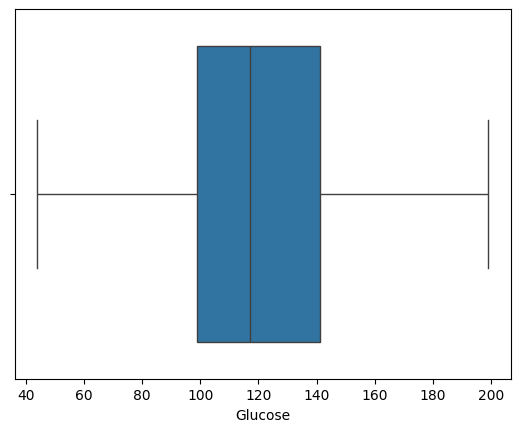

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Glucose'])
plt.show()



**BloodPressure:**


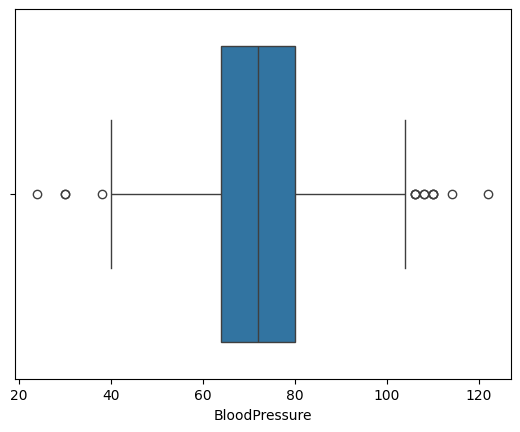

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['BloodPressure'])
plt.show()

**SkinThickness:**

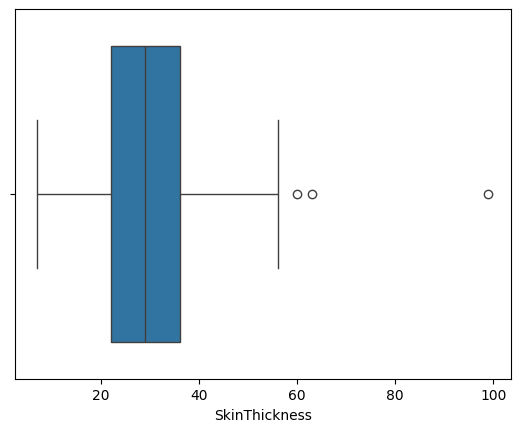

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['SkinThickness'])
plt.show()

**Insulin:**

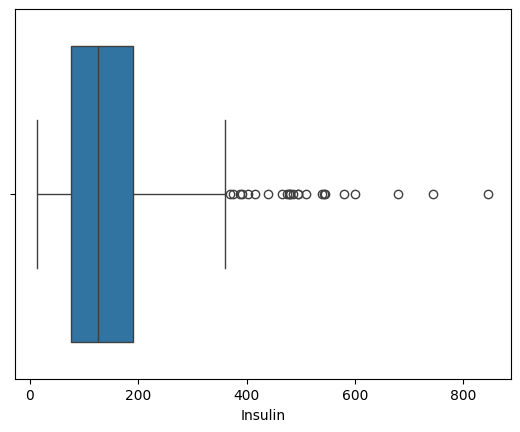

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Insulin'])
plt.show()

**BMI:**

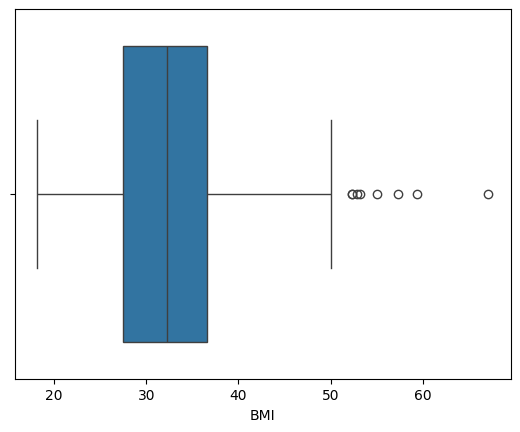

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['BMI'])
plt.show()

**Detectar valores extremos estatisticamente:**

In [15]:
numericas = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

for coluna in numericas:

    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    n_outliers = df[
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ].shape[0]

    print(f"{coluna}: {n_outliers} outliers")

Pregnancies: 4 outliers
Glucose: 0 outliers
BloodPressure: 14 outliers
SkinThickness: 3 outliers
Insulin: 24 outliers
BMI: 8 outliers
DiabetesPedigreeFunction: 29 outliers
Age: 9 outliers


**Faça a divisão dos dados:**

*   70% para treino
*   15% para validação
*   15% para teste


**Separar atributos e saída:**

In [16]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

**Primeira divisão:**



*   70% treino
*   30% temporário





In [20]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

**Segunda divisão:**



*   15% validação
*   15% teste



In [21]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

**Conferindo tamanhos:**

In [22]:
print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (537, 8)
Validação: (115, 8)
Teste: (116, 8)


# **Exercício 2 - Construção MLP**

1. Proponha uma arquiterura de MLP, defina os hiperparâmetros, otimizador, função de perda.
2. Faça o treinamento da rede e apresente:
  - Acurácia no conjunto de teste.
  - Matriz de confusão.
  - Relatório de classificação.

Use como exemplo a aula colab.

```python
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
# --- Acurácia
acc_test = accuracy_score(y_true_test, y_pred_test)
print(f"Acurácia no conjunto de teste: {acc_test:.4f}")

# --- Matriz de confusão
cm = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão (Teste)')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()

# --- Relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_true_test, y_pred_test, digits=4, zero_division=1))
```

# **Exercício 3 - Perguntas finais para discussão crítica**

1. Como a arquitetura do MLP influenciou os resultados obtidos?
2. A seleção de variáveis melhorou a generalização do modelo? Justifique com evidências.
3. Houve sinais de overfitting durante o treinamento? Quais ajustes foram feitos para lidar com isso?
4. Qual foi o impacto da escolha da função de ativação no desempenho final?
5. O número de neurônios por camada afetou a taxa de convergência ou o erro final?
6. A validação durante o treino ajudou a definir uma arquitetura mais estável? Explique.
7. Qual foi a principal limitação do seu modelo mais simples em comparação com os mais complexos?
8. Como os diferentes otimizadores utilizados impactaram a aprendizagem do MLP?
9. Houve inconsistência entre o desempenho no conjunto de validação e no teste? Como interpretá-la?

